# Building Performance Prediction (BPP)

Building Performance Prediction is the quantitative estimation of a proposed building's environmental, structural, and operational behaviors before it is physically constructed.

It uses numerical variables to evaluate how a spatial design will interact with microclimates, occupant behavior, and resource grids over its operational lifetime.

## The Primary Performance Metrics (The Prediction Targets)

In a machine learning workflow, these performance metrics serve as our dependent variables (y-targets). For architects, they represent the core criteria for design viability:

- Energy Use Intensity (EUI): The building's annual energy consumption relative to its gross floor area, typically measured in kWh/m²/year or kBTU/ft²/year. This is the primary metric for tracking operational carbon.

- Spatial Daylight Autonomy (sDA): A geometric and environmental metric defining the percentage of a space that receives sufficient daylight (e.g., 300 lux) for a specified fraction of annual operating hours (e.g., 50%).

- Thermal Comfort Indices (PMV / PPD): Predicted Mean Vote and Predicted Percentage Dissatisfied. These metrics use physiological and environmental factors (air temperature, radiant temperature, humidity, air speed, metabolic rate, and clothing insulation) to mathematically predict human thermal satisfaction in a space.

- Embodied Carbon: The greenhouse gas emissions generated during the extraction, manufacture, transportation, installation, and disposal of physical building materials (concrete, steel, timber).


### Structural and Acoustic Metrics

To predict building performance holistically, a data-driven model must evaluate structural integrity and the acoustic environment alongside thermal and daylighting behaviors.

Structural Metrics (The Mechanics Targets): In early-stage parametric design, predictive structural models prevent the generation of physically impossible or financially unviable geometries.

Instead of running full Finite Element Analysis (FEA) on every iteration, models predict:

- Embodied Carbon In Structural Systems (\($EC_{str}$\)): Measured in \($\text{kg CO}_2\text{e/m}^2$\). Structural materials (concrete, steel) usually account for 50–70% of a building's upfront embodied carbon. This metric tracks the carbon impact of structural sizing choices.

- Total Structural Mass (\($M_{tot}$\)): Measured in kilograms (\($\text{kg}$\)) or tonnes (\($\text{t}$\)). It measures the raw weight of the framing, slabs, and columns to give a direct indicator of material cost and foundation load requirements.

- Maximum Deflection (\($\delta _{max}$\)): Measured in millimeters (\($\text{mm}$\)). The maximum displacement of a structural member under design loads (dead, live, wind, seismic). This is typically constrained by code limits (e.g., \(L/360\) of the span).

- Utilization Ratio (\($U_{max}$\)): A dimensionless ratio (\(\le 1.0\)) comparing internal acting stress to the maximum allowable material capacity. A ratio of \(0.95\) indicates highly optimized efficiency. A ratio of \(0.20\) indicates an over-designed, wasteful structural member.

- Fundamental Natural Frequency (\($f_{1}$\)): Measured in Hertz (\($\text{Hz}$\)). The lowest natural frequency of a structural system. Predicting this ensures the building massing resists wind or seismic excitation and avoids floor vibrations from occupant footsteps.

### Acoustic Metrics (The Indoor Environmental Quality Targets)

Acoustic comfort directly dictates spatial functionality. Predictive models evaluate room acoustics (geometry and absorption) and environmental building envelope performance:

- Reverberation Time (\($RT_{60}$\)): Measured in seconds (\($\text{s}$\)). The time required for the sound pressure level to decrease by 60 decibels after the sound source has ceased. This serves as the primary metric for speech intelligibility (target \($0.6–0.8\text{s}$\) for classrooms) and musical clarity.

- Sound Transmission Class (STC) / Apparent Sound Transmission Class (ASTC): An integer rating characterizing how well a building facade or interior wall assembly attenuates airborne sound. High STC ratings (e.g., \($\ge 50$\)) prevent external traffic noise or adjacent room audio from penetrating a space.

- Useful Noise Criterion (NC) / Noise Rating (NR): A single-number rating used to specify the maximum permissible continuous background noise level in a room, predominantly tracking mechanical HVAC equipment rumble and hum.

- Speech Transmission Index (STI): A dimensionless scale from \($0$\) (completely unintelligible) to \($1$\) (perfect intelligibility) that quantifies speech transmission quality under current room geometry, background noise, and reverberation conditions.


## The Core Problem: Why Do We Need Prediction?

The fundamental challenge in architectural design is that geometry dictates physics, but physics is invisible during design.

The Irreversibility of Early Decisions:

Up to 80% of a building's lifecycle environmental impact is determined by decisions made during the first 20% of the design phase (massing, orientation, window-to-wall ratios, structural grid selection).The

- Complexity of Feedback Loops: Architectural design involves conflicting multi-objective problems.
For example, increasing window area improves daylighting (\($sDA \uparrow$\)), but simultaneously increases summer solar heat gain (\($EUI \uparrow$\)) and risk of visual discomfort (\($Glare \uparrow$\)).

- The Evaluative Void: Architects traditionally rely on visual intuition, historical precedent, or rigid building codes to guess these outcomes.

BPP provides an objective, computational mechanism to transform qualitative design intuition into verifiable, data-backed evidence.


# The Data Pipeline — Translating Spatial Design into Features

To train a machine learning model, multi-dimensional physical architecture must be flattened into structured numerical data (a pandas DataFrame). This process is called Feature Engineering for Architecture.

|[ Rhino Geometry ] ────> |[ Grasshopper Script ] ────> |[ Pandas DataFrame ]|
|-|-|-|
  |• Brep Area|              • Extract Dimensions   |      • Columns: Features (X)|
 | • Orientation  |          • Calculate Ratios  |         • Rows: Design Options|
 | • Window Mesh    |        • Compute Matrices    |       • Values: Numbers|


 ## Feature Types in Built Environment Modeling

 When building a surrogate prediction model, the features (Independent Variables, \(X\)) are categorized into design parameters and environmental constraints:

 Geometric Features (Continuous/Discrete):

 - Aspect Ratio (\(AR\)): Ratio of building length to width (\(L/W\)).

 - Window-to-Wall Ratio (\(WWR\)): \($\frac{\text{Total\ Glazing\ Area}}{\text{Total\ Facade\ Area}}$\). This is a critical predictor for daylight, cooling, heating, and acoustic transmission.

 - Surface-to-Volume Ratio (\($S/V$\)): A metric for building compactness. High ratios mean high exposure to external climate conditions.

 - Shading Factor (\($SF$\)): Ratio of shading projection depth to window height

 Material/Assembly Features (Discrete Categorical or Continuous Engine Values):

 - Thermal Transmittance (\($U$\)$-value$): Measured in \($\text{W/m}^2\text{K}$\). Tracks insulation performance of walls, roofs, and glass.

 - Solar Heat Gain Coefficient (\($SHGC$\)): A value between \($0$\) and \($1$\) measuring a window's ability to admit solar radiation.

 - Material Density & Elastic Modulus (\($E$\)): Structural inputs for concrete/steel grades or mass timber types.

 Contextual/Boundary Features (Constants per model run):

 - Orientation: Measured in degrees (\($0^\circ - 360^\circ$\)).

 - Context Shading Density: Percentage of sky dome blocked by neighboring high-rises.

 - Weather Data Features: Annual Heating Degree Days (HDD), Cooling Degree Days (CDD), and Direct Normal Irradiance (DNI) extracted from climate .epw files.

 ## Synthetic Data Generation via Parametric Toolchains

 Real-world operational building data is notoriously noisy, incomplete, and difficult to obtain due to privacy restrictions. Therefore, architectural machine learning relies heavily on Synthetic Data Generation.

 ### The Generation Loop (Rhino + Grasshopper + Ladybug Tools)

 Define Parametric Ranges: Setup native Grasshopper sliders for inputs. For example, vary \(WWR\) from \($0.20$\) to \($0.80$\) in steps of \($0.05$\). Vary Orientation from \($0^{\circ }$\) to \($360^{\circ }$\) in steps of \($15^{\circ }$\).

 - Automate Execution: Use a Python loop component in Grasshopper or a plugin like Colibri to systematically iterate through all combinations of inputs.

 - Execute the Physics Core: For each geometric variation, call the respective simulation engine locally in the background:Thermal/Energy:

 - EnergyPlusDaylighting: RadianceStructural: Karamba3D / OpenSeesAcoustics: Pachyderm Acoustic / I-Simpa

 - Extract and Flatten: Capture the input slider parameters (\(X\)) and the resulting simulation output metrics (\(y\)). Append them as a single horizontal array row into a master matrix.

 - Export: Save the completed multi-variate matrix as a .csv file. This file functions as the raw dataset used to train the machine learning surrogate model.



# Implementation
This section outlines the code cell blocks and explanations to train a Multi-Objective Surrogate Performance Predictor from an architectural dataset.

In [ ]:
# 1. Generating a Synthetic Architectural Dataset

import numpy as np
import pandas as pd

# Set random seed for repeatability
np.random.seed(42)
n_samples = 1200

# Generate Architectural Features (X)
wwr = np.random.uniform(0.15, 0.85, n_samples)          # Window-to-Wall Ratio
orientation = np.random.uniform(0, 360, n_samples)       # Degrees
shading_depth = np.random.uniform(0.0, 1.5, n_samples)  # Meters
cantilever_length = np.random.uniform(0.0, 3.0, n_samples) # Structural span projection

# Generate Performance Targets (y) using deterministic approximations with added noise
# Cooling load increases with WWR, increases if oriented South (180), decreases with shading
cooling_load = (wwr * 150) - (shading_depth * 30) + (np.sin(np.radians(orientation)) * 15) + 40
cooling_load += np.random.normal(0, 5, n_samples) # Add Gaussian sensor/environmental noise

# Embodied Carbon increases dramatically with cantilever length due to required structural reinforcement
embodied_carbon = (cantilever_length ** 2 * 45) + (wwr * 12) + 120
embodied_carbon += np.random.normal(0, 8, n_samples)

# Assemble DataFrame
df = pd.DataFrame({
    'WWR': wwr,
    'Orientation': orientation,
    'Shading_Depth': shading_depth,
    'Cantilever_Length': cantilever_length,
    'Cooling_Load_kWh': cooling_load,
    'Structural_EC_kgCO2e': embodied_carbon
})

print(f"Dataset generated successfully shape: {df.shape}")
df.head()


Dataset generated successfully shape: (1200, 6)


,WWR,Orientation,Shading_Depth,Cantilever_Length,Cooling_Load_kWh,Structural_EC_kgCO2e
0,0.412178,272.974751,0.510906,0.423671,72.425051,134.564268
1,0.815500,8.851290,0.107568,1.712632,167.922414,280.912792
2,0.662396,7.964479,0.614443,0.555811,125.935280,125.055566
3,0.569061,116.499679,0.466826,0.835929,122.716337,163.739508
4,0.259213,175.911549,1.015681,0.656129,50.766969,141.564899


In [ ]:
# 2. Data Preprocessing & Splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define Inputs (X) and Targets (y)
X = df[['WWR', 'Orientation', 'Shading_Depth', 'Cantilever_Length']]
y = df[['Cooling_Load_kWh', 'Structural_EC_kgCO2e']]

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features so that features with large numerical ranges (e.g. Orientation 0-360)
# do not mathematically overpower features with small ranges (e.g. WWR 0.15-0.85).
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training features size: {X_train_scaled.shape}")
print(f"Testing features size: {X_test_scaled.shape}")


Training features size: (960, 4)
Testing features size: (240, 4)


In [ ]:
# 3. Model Training (Random Forest Regressor)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Initialize the surrogate engine model
surrogate_model = RandomForestRegressor(n_estimators=150, random_state=42)

# Train the model
surrogate_model.fit(X_train_scaled, y_train)

# Predict performance metrics on the unseen test set
y_pred = surrogate_model.predict(X_test_scaled)

# Evaluate performance metrics individually
targets = ['Cooling_Load_kWh', 'Structural_EC_kgCO2e']
for i, col in enumerate(targets):
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    print(f"--- Metric: {col} ---")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"R² Score (Accuracy Metric): {r2:.4f} (Target close to 1.0)")


--- Metric: Cooling_Load_kWh ---
Mean Absolute Error (MAE): 10.49
R² Score (Accuracy Metric): 0.8628 (Target close to 1.0)
--- Metric: Structural_EC_kgCO2e ---
Mean Absolute Error (MAE): 7.38
R² Score (Accuracy Metric): 0.9938 (Target close to 1.0)


In [ ]:
# 4. Serializing the Model for Rhino/Grasshopper Integration

import pickle

# Bundle the model and the data scaler together
model_artifact = {
    'model': surrogate_model,
    'scaler': scaler,
    'feature_names': list(X.columns),
    'target_names': targets
}

# Export to a localized file
with open('architectural_surrogate.pkl', 'wb') as f:
    pickle.dump(model_artifact, f)

print("Export complete. File 'architectural_surrogate.pkl' is ready for download and deployment in Grasshopper!")



Export complete. File 'architectural_surrogate.pkl' is ready for download and deployment in Grasshopper!


# 5. Live Deployment inside Rhino/Grasshopper
# download the architectural_surrogate.pkl file from the Colab notebook, and deploy it directly inside your 3D design workspace.
 [GH Slider] ───> [ GHPython Component ] ───> Live Real-Time Data Graph<br>
                  • Reads Sliders<br>
                  • Unpacks .pkl File<br>
                  • Runs Instant Prediction<br>

## The GHPython Implementation

Inside the Grasshopper canvas, students add a standard GHPython component. They configure 4 input parameters matching the model's inputs exactly: WWR, Orientation, Shading_Depth, and Cantilever_Length.Inside the GHPython component editor, they paste the following deployment script:

In [ ]:
"""
Grasshopper Script running inside the GHPython Component.
Ensure you have the 'scikit-learn' module installed in your Rhino Python environment.
"""

import ghenv
import os
import pickle

# Check if model path is set correctly
# Path points to the file downloaded from your Google Colab instance
model_path = r"C:\path\to\your\directory\architectural_surrogate.pkl"

if os.path.exists(model_path):
    # Load the serialized model package
    with open(model_path, 'rb') as f:
        artifact = pickle.load(f)

    model = artifact['model']
    scaler = artifact['scaler']

    # Format incoming real-time canvas sliders into a 2D array
    input_data = [[WWR, Orientation, Shading_Depth, Cantilever_Length]]

    # Run identical scaling transformations
    input_scaled = scaler.transform(input_data)

    # Compute the millisecond inference calculation
    predictions = model.predict(input_scaled)

    # Route outputs back out to native Grasshopper display components
    Predicted_Cooling_Load = predictions[0][0]
    Predicted_Structural_EC = predictions[0][1]
else:
    print("Warning: Locate the 'architectural_surrogate.pkl' file and verify path accuracy.")


# Multi-Objective Generative Design Optimization

We will move now from prediction to exploration.

## The Optimization Problem

 Architectural design is inherently a multi-objective optimization challenge with competing targets.

 Conflict: Minimizing Cooling_Load_kWh requires shrinking windows (\($WWR \downarrow$\)). Maximizing Spatial Daylight Autonomy requires expanding windows (\($WWR \uparrow$\)).

 The Solution Space: There is no single "perfect" building shape. Instead, there is a collection of optimized trade-off options called the Pareto Optimal Front.

 ## The Bottleneck of Traditional Genetic Algorithms (GA)

 In standard architecture, plugins like Wallacei or Octopus use Genetic Algorithms to search for these Pareto forms.The GA generates 100 random structural shapes (Generation 1).It sends all 100 shapes to a physics engine (EnergyPlus/Radiance).The physics engine takes 3 minutes per shape. Total time for Generation 1 to 5 hours.To find a true optimized shape, the GA needs to process 50 generations. Total Optimization Time = 250 hours (Over 10 Days). This makes optimization impossible during real-world design studio timelines.

 ## The ML-Accelerated Optimization Loop

 By substituting the slow physics engine with the custom ML Surrogate Model inside the evolutionary optimization loop, the runtime dynamics shift completely:

 - The GA generates 100 structural options.

 - The options feed directly into the surrogate_model. predict() function.

 - The ML model evaluates all 100 designs in 0.02 seconds.Processing 50 generations takes under 2 seconds total.

 - This radical acceleration allows you to run multi-objective optimization interactively during reviews, letting you explore thousands of high-performance architectural variations in real time.

## Visualizing the Pareto Optimal Front in Python

### Pareto Front

A Pareto Front (or Pareto Frontier) is a mathematical boundary that represents the absolute best possible trade-offs between two or more conflicting design objectives.

A design point is considered Pareto optimal if it is impossible to improve one performance metric without making at least one other performance metric worse. The collection of all these optimal points forms a non-dominated boundary curve.

### The Concept of Pareto Optimality

When dealing with conflicting architectural goals (e.g., minimizing cooling loads while simultaneously minimizing structural embodied carbon), we rarely find a single "perfect" design. Instead, we look for Pareto efficient options. A design option is Pareto optimal if you cannot improve one metric without actively worsening the other. The boundary formed by these optimal points is called the Pareto Front.


To isolate the front, the machine learning or genetic algorithm evaluates every generated design variation based on the concept of Domination:

- Dominated Designs (Sub-Optimal): A design option is "dominated" if there is another configuration available that performs better in both metrics simultaneously. These points are discarded from the final selection.

- Non-Dominated Designs (Pareto Optimal): A design option is "non-dominated" if no other configuration exists that can beat it in both columns. These options are saved.

### The Architectural Value of the Front

The Pareto Front does not make the final design decision for the architect; it clears away the noise.Instead of forcing an architect to guess between 5,000 random structural variations, the Pareto Front filters those choices down to a clean curve of perhaps 20 highly-efficient options. It allows you to shift focus from technical guessing to high-level architectural curation—choosing the specific compromise along that curve that best fits your aesthetic, cultural, or spatial goals for the studio project.

The code cell below generates a random design exploration space, filters the dataset down to the mathematically optimal Pareto choices, and maps the results using matplotlib.

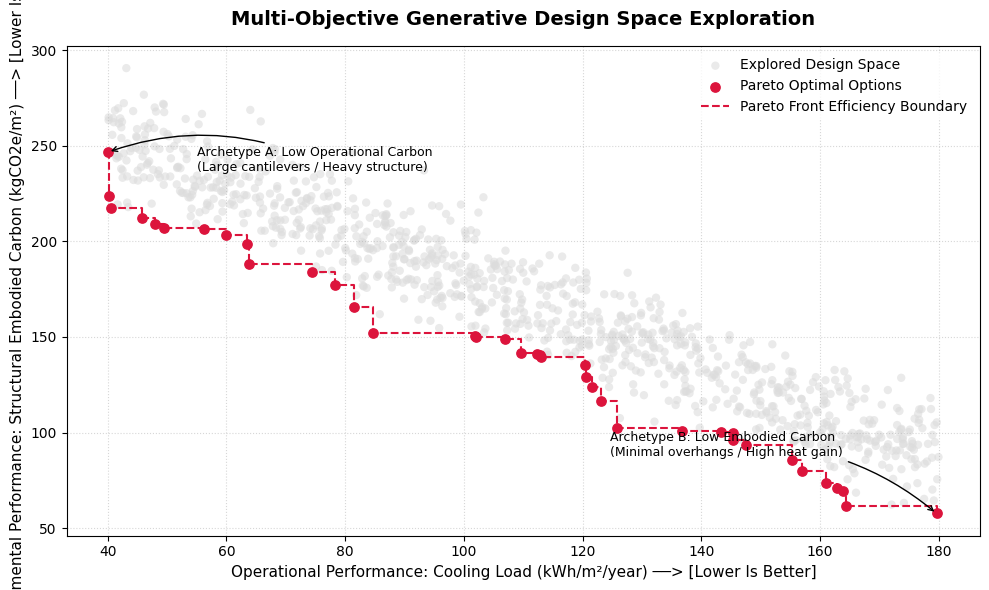

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Generate a large pool of candidate architectural designs using our surrogate model
# For visualization purposes, we will simulate a design space of 1,000 potential options
np.random.seed(101)
n_designs = 1000

# Generate simulated predictions (Cooling Load vs Structural Embodied Carbon)
# Notice the inverse relationship: deeper cantilevers lower cooling via shading but increase structural carbon
cooling_predicted = np.random.uniform(40, 180, n_designs)
carbon_predicted = 300 - (cooling_predicted * 1.2) + np.random.normal(0, 15, n_designs)

# Create a DataFrame of our design options
design_space = pd.DataFrame({
    'Cooling_Load_kWh': cooling_predicted,
    'Structural_EC_kgCO2e': carbon_predicted
})

# 2. Identify the Pareto Optimal points (Minimizing BOTH objectives)
def identify_pareto_front(df, x_col, y_col):
    """
    Finds the pareto optimal points for a minimization-minimization problem.
    """
    sorted_df = df.sort_values(by=[x_col, y_col]).values
    pareto_front = [sorted_df[0]]

    for row in sorted_df[1:]:
        if row[1] < pareto_front[-1][1]: # If the y-value is lower (better) than the last added item
            pareto_front.append(row)

    return pd.DataFrame(pareto_front, columns=[x_col, y_col])

pareto_df = identify_pareto_front(design_space, 'Cooling_Load_kWh', 'Structural_EC_kgCO2e')

# Sort the front chronologically for clean line drawing
pareto_df = pareto_df.sort_values(by='Cooling_Load_kWh')

# 3. Create the Matplotlib Plot
plt.figure(figsize=(10, 6), dpi=100)

# Scatter plot of all sub-optimal design variations explored by the algorithm
plt.scatter(design_space['Cooling_Load_kWh'], design_space['Structural_EC_kgCO2e'],
            c='gainsboro', alpha=0.6, edgecolors='none', label='Explored Design Space')

# Highlight the optimized Pareto options
plt.scatter(pareto_df['Cooling_Load_kWh'], pareto_df['Structural_EC_kgCO2e'],
            c='crimson', s=45, zorder=3, label='Pareto Optimal Options')

# Step line trace connecting the Pareto choices to define the structural boundary
plt.step(pareto_df['Cooling_Load_kWh'], pareto_df['Structural_EC_kgCO2e'],
         where='post', color='crimson', linestyle='--', linewidth=1.5, label='Pareto Front Efficiency Boundary')

# Graph aesthetics and clear labeling for architecture students
plt.title('Multi-Objective Generative Design Space Exploration', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Operational Performance: Cooling Load (kWh/m²/year) ──> [Lower Is Better]', fontsize=11)
plt.ylabel('Environmental Performance: Structural Embodied Carbon (kgCO2e/m²) ──> [Lower Is Better]', fontsize=11)

# Annotate specific compromise archetypes to facilitate architectural sensemaking
plt.annotate('Archetype A: Low Operational Carbon\n(Large cantilevers / Heavy structure)',
             xy=(pareto_df['Cooling_Load_kWh'].min(), pareto_df['Structural_EC_kgCO2e'].max()),
             xytext=(pareto_df['Cooling_Load_kWh'].min() + 15, pareto_df['Structural_EC_kgCO2e'].max() - 10),
             arrowprops=dict(arrowstyle="->", color="black", connectionstyle="arc3,rad=.2"), fontsize=9)

plt.annotate('Archetype B: Low Embodied Carbon\n(Minimal overhangs / High heat gain)',
             xy=(pareto_df['Cooling_Load_kWh'].max(), pareto_df['Structural_EC_kgCO2e'].min()),
             xytext=(pareto_df['Cooling_Load_kWh'].max() - 55, pareto_df['Structural_EC_kgCO2e'].min() + 30),
             arrowprops=dict(arrowstyle="->", color="black", connectionstyle="arc3,rad=-.2"), fontsize=9)

plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()

# Render the output
plt.show()